In [8]:
import pandas as pd
import numpy as np

from scipy.stats import chi2_contingency

import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df_commercial_activity = pd.read_csv('data/datasets_TFM + diccionario/customer_commercial_activity.csv', sep=',')
df_commercial_activity

,Unnamed: 0,pk_cid,pk_partition,entry_date,entry_channel,active_customer,segment
0,0,1375586,2018-01,2018-01,KHL,1.0,02 - PARTICULARES
1,1,1050611,2018-01,2015-08,KHE,0.0,03 - UNIVERSITARIO
2,2,1050612,2018-01,2015-08,KHE,0.0,03 - UNIVERSITARIO
3,3,1050613,2018-01,2015-08,KHD,0.0,03 - UNIVERSITARIO
4,4,1050614,2018-01,2015-08,KHE,1.0,03 - UNIVERSITARIO
...,...,...,...,...,...,...,...
5962919,13647304,1166765,2019-05,2016-08,KHE,0.0,03 - UNIVERSITARIO
5962920,13647305,1166764,2019-05,2016-08,KHE,0.0,03 - UNIVERSITARIO
5962921,13647306,1166763,2019-05,2016-08,KHE,1.0,02 - PARTICULARES
5962922,13647307,1166789,2019-05,2016-08,KHE,0.0,03 - UNIVERSITARIO


-	**pk_cid**:	Identificador de cliente
-	**pk_partition**:	Identificador de Partición. Mensualmente se ingesta en la tabla una partición con el estado de la base de clientes.
-	**entry_channel**:	Canal de captación del cliente
-	**entry_date**:	Fecha en la que realizó la primera contratación a través de easyMoney
-	**segment**:	Segmento comercial del cliente
-	**active_customer**:	Indicador de actividad del cliente en la app EasyMoney

In [10]:
df_commercial_activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5962924 entries, 0 to 5962923
Data columns (total 7 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Unnamed: 0       int64  
 1   pk_cid           int64  
 2   pk_partition     object 
 3   entry_date       object 
 4   entry_channel    object 
 5   active_customer  float64
 6   segment          object 
dtypes: float64(1), int64(2), object(4)
memory usage: 318.5+ MB


In [11]:
print("Número de registros: {}".format(df_commercial_activity.pk_cid.count()))
print("Número de ids únicos: {}".format(df_commercial_activity.pk_cid.nunique()))

Número de registros: 5962924
Número de ids únicos: 456373


## Nulos

In [12]:
df_commercial_activity[df_commercial_activity.isnull().all(axis=1)]

,Unnamed: 0,pk_cid,pk_partition,entry_date,entry_channel,active_customer,segment


In [13]:
df_commercial_activity.select_dtypes(include=['number']).isnull().sum().sort_values(ascending=False)

Unnamed: 0         0
pk_cid             0
active_customer    0
dtype: int64

In [14]:
df_commercial_activity.select_dtypes(include=['object']).isnull().sum().sort_values(ascending=False)

segment          133944
entry_channel    133033
pk_partition          0
entry_date            0
dtype: int64

In [15]:
cols_with_nulls = ['segment','entry_channel']

for col in cols_with_nulls:
    null_pct = (df_commercial_activity[col].isnull().sum() / len(df_commercial_activity)) * 100
    print(f'% de nulos en {col}: {null_pct:.2f}%')

% de nulos en segment: 2.25%
% de nulos en entry_channel: 2.23%


In [16]:
# rellenamos los pocos nulos qeu hay con la moda de su partición
mode_segment = df_commercial_activity.groupby('pk_partition')['segment'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
mode_channel = df_commercial_activity.groupby('pk_partition')['entry_channel'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)

df_commercial_activity['segment'] = df_commercial_activity['segment'].fillna(df_commercial_activity['pk_partition'].map(mode_segment))
df_commercial_activity['entry_channel'] = df_commercial_activity['entry_channel'].fillna(df_commercial_activity['pk_partition'].map(mode_channel))

# Análisis exploratorio 

In [17]:
stats = []
for col in df_commercial_activity.columns:
    stats.append((col, df_commercial_activity[col].nunique(), df_commercial_activity[col].isnull().sum() * 100 / df_commercial_activity.shape[0], df_commercial_activity[col].value_counts(normalize=True, dropna=False).values[0] * 100, df_commercial_activity[col].dtype))

stats_df_commercial_activity_commercial_activity = pd.DataFrame(stats, columns=['Feature', 'Unique_values', '% missing values', '% values in biggest category', 'type'])
stats_df_commercial_activity_commercial_activity = stats_df_commercial_activity_commercial_activity.sort_values(by=[ '% values in biggest category','Unique_values'], ascending=[False, True])
display(stats_df_commercial_activity_commercial_activity)

,Feature,Unique_values,% missing values,% values in biggest category,type
6,segment,3,0.0,67.653218,object
5,active_customer,2,0.0,59.661552,float64
4,entry_channel,68,0.0,54.452815,object
2,pk_partition,17,0.0,7.429157,object
3,entry_date,53,0.0,6.414185,object
1,pk_cid,456373,0.0,0.000285,int64
0,Unnamed: 0,5962924,0.0,0.000017,int64


In [18]:
for col in [c for c in df_commercial_activity.columns if c not in ['pk_cid', 'Unnamed: 0']]:
    print(f"\n=== {col} ===")
    print(df_commercial_activity[col].value_counts(dropna=False))


=== pk_partition ===
pk_partition
2019-05    442995
2019-04    439627
2019-03    436183
2019-02    431727
2019-01    426875
2018-12    422481
2018-11    416387
2018-10    402300
2018-09    375323
2018-08    352922
2018-07    339339
2018-06    252104
2018-05    249926
2018-04    247463
2018-03    245258
2018-02    242521
2018-01    239493
Name: count, dtype: int64

=== entry_date ===
entry_date
2016-10    382473
2017-10    340613
2015-10    310295
2017-09    294752
2017-07    267173
2016-08    252704
2015-08    221984
2015-07    220941
2017-11    217751
2015-09    217174
2018-10    216947
2015-11    210687
2016-09    206107
2018-09    202262
2016-07    189225
2016-11    188601
2018-07    178215
2017-08    162534
2018-08    138420
2017-12    123456
2018-11    103073
2016-12     89423
2015-12     82347
2017-01     65539
2018-02     61283
2018-01     59721
2017-06     54925
2018-03     51022
2016-01     50830
2017-02     50561
2017-03     50268
2017-05     50165
2017-04     47729
2018-04 

### 1. Tasa de actividad

In [19]:
# Clientes totales, activos y tasa de actividad
metrics_partition = (
    df_commercial_activity.groupby('pk_partition')
      .agg(
          total_clients=('pk_cid', 'nunique'),
          active_clients=('active_customer', lambda x: (x == 1).sum()),
          inactive_clients=('active_customer', lambda x: (x == 0).sum()),
          unique_channels=('entry_channel', 'nunique'),
          unique_segments=('segment', 'nunique')
      )
      .reset_index()
)

metrics_partition['activity_rate'] = metrics_partition['active_clients'] / metrics_partition['total_clients']
metrics_partition

,pk_partition,total_clients,active_clients,inactive_clients,unique_channels,unique_segments,activity_rate
0,2018-01,239493,108211,131282,51,3,0.451834
1,2018-02,242521,111085,131436,51,3,0.458043
2,2018-03,245258,113806,131452,53,3,0.464026
3,2018-04,247463,116318,131145,53,3,0.470042
4,2018-05,249926,119066,130860,53,3,0.476405
5,2018-06,252104,121560,130544,54,3,0.482182
6,2018-07,339339,129287,210052,63,3,0.380997
7,2018-08,352922,136350,216572,64,3,0.386346
8,2018-09,375323,144787,230536,63,3,0.385766
9,2018-10,402300,151962,250338,64,3,0.377733


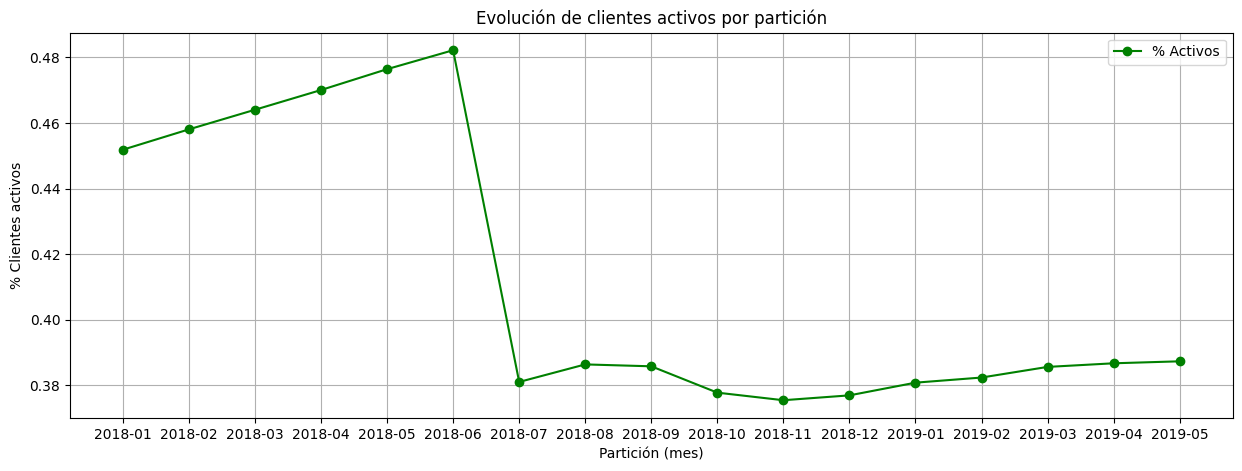

In [20]:
# Evolución de actividad
plt.figure(figsize=(15,5))
plt.plot(metrics_partition['pk_partition'], metrics_partition['activity_rate'], marker='o', color='green', label='% Activos')
plt.title('Evolución de clientes activos por partición')
plt.xlabel('Partición (mes)')
plt.ylabel('% Clientes activos')
plt.grid(True)
plt.legend()
plt.show()

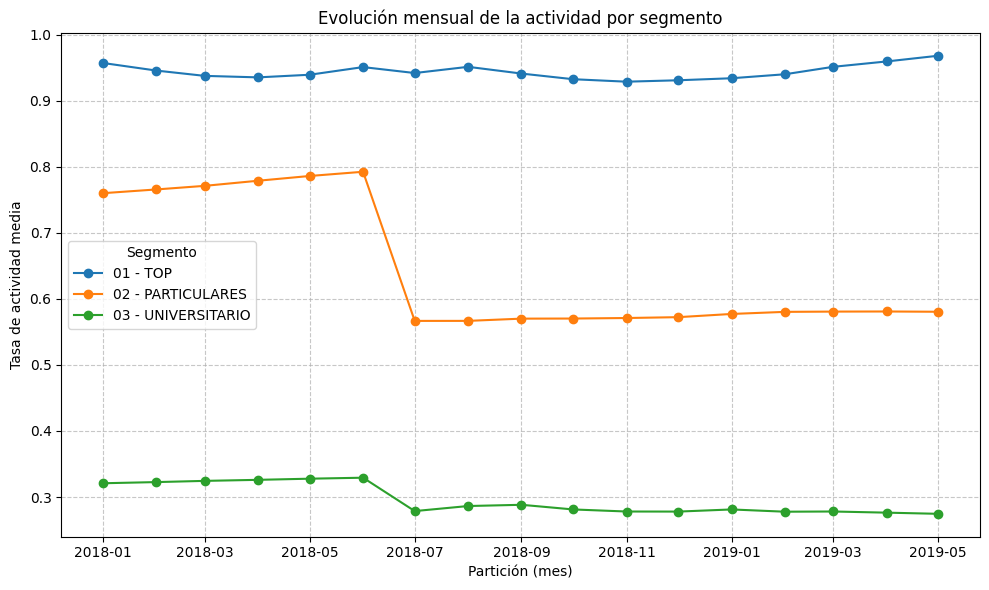

In [21]:
df_commercial_activity['pk_partition'] = pd.to_datetime(df_commercial_activity['pk_partition'], errors='coerce')

# Cálculo de tasa media de actividad por segmento y mes
activity_segment = (
    df_commercial_activity.groupby(['pk_partition', 'segment'])['active_customer']
      .mean()
      .reset_index()
)

# Evolución de la actividad por segmento

plt.figure(figsize=(10,6))

for segment in activity_segment['segment'].unique():
    seg_data = activity_segment[activity_segment['segment'] == segment].sort_values('pk_partition')
    plt.plot(seg_data['pk_partition'], seg_data['active_customer'], marker='o', label=segment)

plt.title("Evolución mensual de la actividad por segmento")
plt.xlabel("Partición (mes)")
plt.ylabel("Tasa de actividad media")
plt.legend(title="Segmento")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


### 2. Nuevos clientes

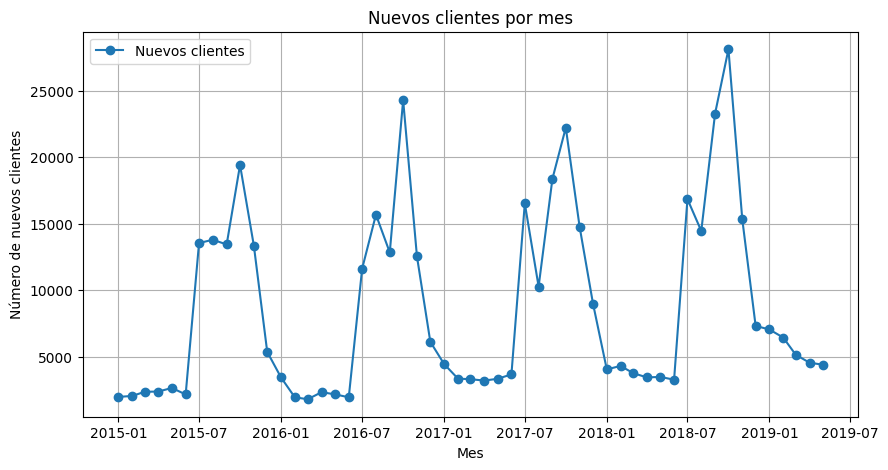

In [22]:
# Nuevos clientes por mes (por entry_date)
df_commercial_activity['entry_date'] = pd.to_datetime(df_commercial_activity['entry_date'], errors='coerce')

clientes_mes = df_commercial_activity.groupby(df_commercial_activity['entry_date'].dt.to_period('M'))['pk_cid'].nunique()
clientes_mes.index = clientes_mes.index.to_timestamp()

plt.figure(figsize=(10,5))
plt.plot(clientes_mes.index, clientes_mes.values, marker='o', label='Nuevos clientes')
plt.title('Nuevos clientes por mes')
plt.xlabel('Mes')
plt.ylabel('Número de nuevos clientes')
plt.grid(True)
plt.legend()
plt.show()

### 3. Antigüedad de los clientes

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_36727/440606736.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  activity_by_age = df_clean.groupby('age_group')['active_customer'].mean().reindex(labels)


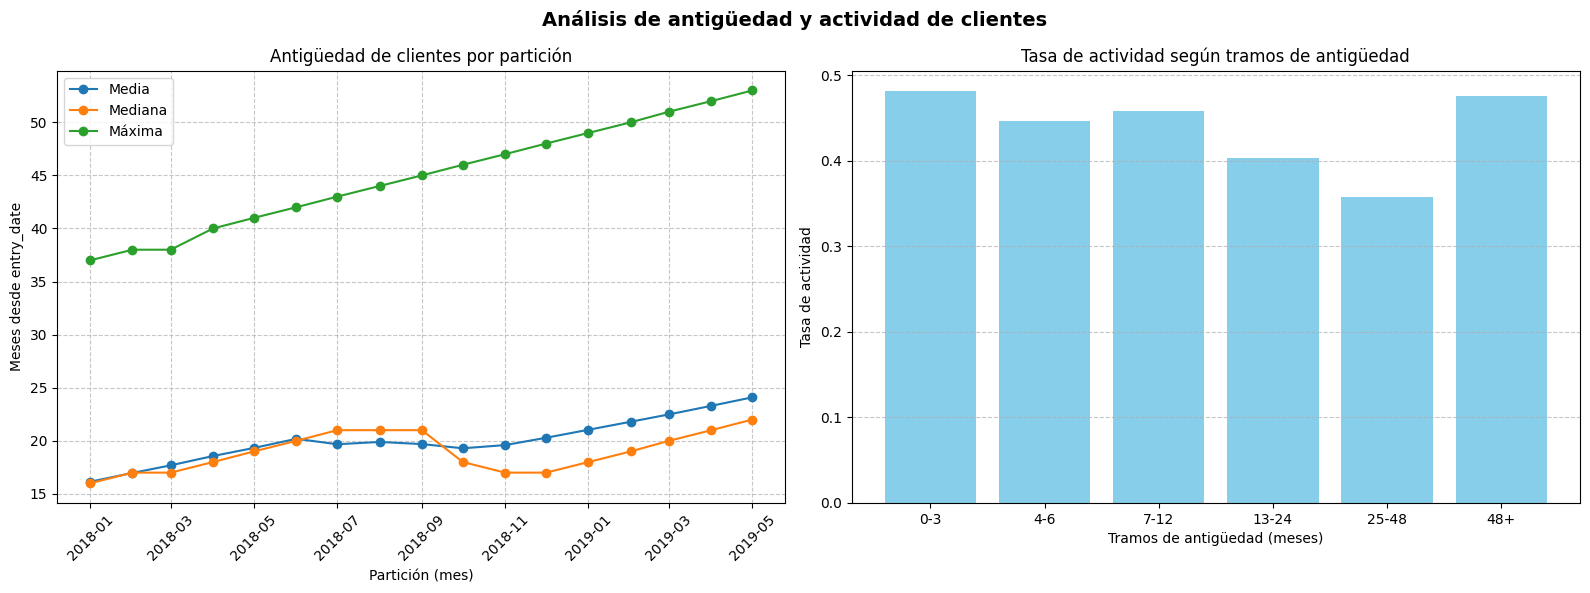

In [23]:
df_commercial_activity['pk_partition'] = pd.to_datetime(df_commercial_activity['pk_partition'], errors='coerce')
df_commercial_activity['entry_date'] = pd.to_datetime(df_commercial_activity['entry_date'], errors='coerce')


df_commercial_activity['months_since_entry'] = (
    (df_commercial_activity['pk_partition'] - df_commercial_activity['entry_date']).dt.days / 30
).round()

# Eliminamos filas con NaN en months_since_entry (fechas inválidas)
df_clean = df_commercial_activity.dropna(subset=['months_since_entry'])


antiguedad_stats = (
    df_clean.groupby('pk_partition')['months_since_entry']
    .agg(['mean', 'median', 'max'])
    .reset_index()
)

bins = [0, 3, 6, 12, 24, 48, np.inf]
labels = ['0-3','4-6','7-12','13-24','25-48','48+']
df_clean['age_group'] = pd.cut(df_clean['months_since_entry'], bins=bins, labels=labels, right=True)

activity_by_age = df_clean.groupby('age_group')['active_customer'].mean().reindex(labels)


fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=False)

# (a) Evolución de antigüedad
axes[0].plot(antiguedad_stats['pk_partition'], antiguedad_stats['mean'], marker='o', label='Media')
axes[0].plot(antiguedad_stats['pk_partition'], antiguedad_stats['median'], marker='o', label='Mediana')
axes[0].plot(antiguedad_stats['pk_partition'], antiguedad_stats['max'], marker='o', label='Máxima')
axes[0].set_title("Antigüedad de clientes por partición")
axes[0].set_xlabel("Partición (mes)")
axes[0].set_ylabel("Meses desde entry_date")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].tick_params(axis='x', rotation=45)

# (b) Tasa de actividad por tramos de antigüedad
axes[1].bar(activity_by_age.index, activity_by_age.values, color='skyblue')
axes[1].set_title("Tasa de actividad según tramos de antigüedad")
axes[1].set_xlabel("Tramos de antigüedad (meses)")
axes[1].set_ylabel("Tasa de actividad")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle("Análisis de antigüedad y actividad de clientes", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4. Churn and Retention rates

In [24]:
# Métricas de churn y retención entre particiones

partitions = sorted(df_commercial_activity['pk_partition'].unique())
churn_data = []

for i in range(1, len(partitions)):
    prev_month = df_commercial_activity[df_commercial_activity['pk_partition'] == partitions[i-1]]
    curr_month = df_commercial_activity[df_commercial_activity['pk_partition'] == partitions[i]]

    prev_active = set(prev_month.loc[prev_month['active_customer'] == 1, 'pk_cid'])
    curr_active = set(curr_month.loc[curr_month['active_customer'] == 1, 'pk_cid'])

    retained = len(prev_active & curr_active)
    churned = len(prev_active - curr_active)
    new = len(curr_active - prev_active)

    churn_data.append({
        'pk_partition': partitions[i],
        'retained': retained,
        'churned': churned,
        'new': new,
        'retention_rate': retained / len(prev_active) if len(prev_active) > 0 else np.nan,
        'churn_rate': churned / len(prev_active) if len(prev_active) > 0 else np.nan
    })

churn_df = pd.DataFrame(churn_data)
churn_df

,pk_partition,retained,churned,new,retention_rate,churn_rate
0,2018-02-01,108107,104,2978,0.999039,0.000961
1,2018-03-01,110966,119,2840,0.998929,0.001071
2,2018-04-01,113667,139,2651,0.998779,0.001221
3,2018-05-01,116244,74,2822,0.999364,0.000636
4,2018-06-01,118954,112,2606,0.999059,0.000941
5,2018-07-01,121560,0,7727,1.000000,0.000000
6,2018-08-01,125641,3646,10709,0.971799,0.028201
7,2018-09-01,132619,3731,12168,0.972637,0.027363
8,2018-10-01,140715,4072,11247,0.971876,0.028124
9,2018-11-01,147594,4368,8727,0.971256,0.028744


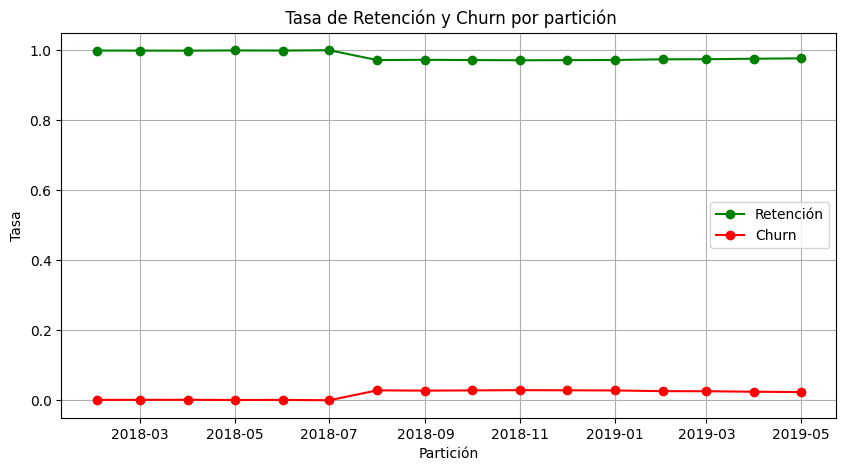

In [25]:
plt.figure(figsize=(10,5))
plt.plot(churn_df['pk_partition'], churn_df['retention_rate'], marker='o', label='Retención', color='green')
plt.plot(churn_df['pk_partition'], churn_df['churn_rate'], marker='o', label='Churn', color='red')
plt.title(' Tasa de Retención y Churn por partición')
plt.xlabel('Partición')
plt.ylabel('Tasa')
plt.grid(True)
plt.legend()
plt.show()

## Guardado datos PBI

In [26]:
df_commercial_activity.to_csv('data/pbi_datasets/customer_commercial_activity_pbi.csv', sep=',')